<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/graviationalwave_GW170608.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Graviational Wave GW170608**

GW170608 war ein Gravitationswellensignal, das durch zwei kollidierende schwarze Löcher entstand. Durch die Kollision wurde aus zwei schwarzen Löchern mit etwa 12 Sonnenmassen und 7 Sonnenmassen ein größeres schwarzes Loch mit 18 Sonnenmassen, wobei eine Sonnenmasse in Energie in Form von Gravitationswellen umgewandelt wurde. Das Signal wurde am 8. Juni 2017 um 02:01:16.49 UTC von zwei LIGO-Detektoren registriert.

https://de.m.wikipedia.org/wiki/GW170608

In [1]:
!pip install gwpy matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00


In [ ]:
from gwpy.timeseries import TimeSeries
import matplotlib.pyplot as plt

# Define the event time for GW170814
event_time = 1180922494.5  # GPS time of GW170608

# Load strain data for Hanford, Livingston, and Virgo detectors
hanford_data = TimeSeries.fetch_open_data('H1', event_time - 16, event_time + 16, cache=True)
livingston_data = TimeSeries.fetch_open_data('L1', event_time - 16, event_time + 16, cache=True)

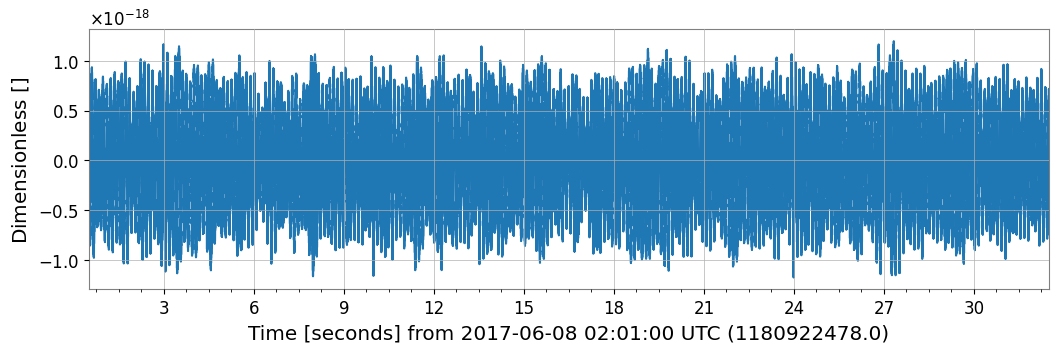

In [7]:
plot_h1a = hanford_data.plot()
plt.show()

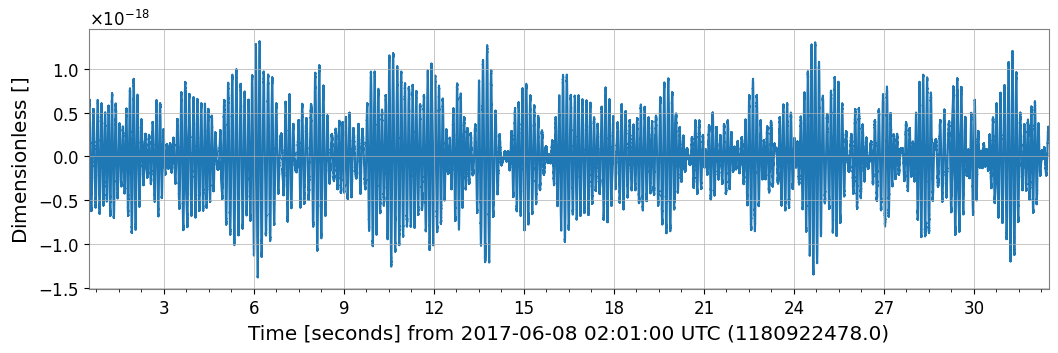

In [8]:
plot_l1a = livingston_data.plot()
plt.show()

In [12]:
# Apply a bandpass filter between 30 and 400 Hz to remove noise outside this range
hanford_data_bp = hanford_data.bandpass(30, 400)
livingston_data_bp = livingston_data.bandpass(30, 400)

# Whiten the data to make the noise spectrum flat across frequencies
hanford_data_white = hanford_data_bp.whiten()
livingston_data_white = livingston_data_bp.whiten()

# Generate a Q-transform plot of the whitened data around the event time
q_transform_h1 = hanford_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))
q_transform_l1 = livingston_data_white.q_transform(outseg=(event_time-0.2, event_time + 0.2))

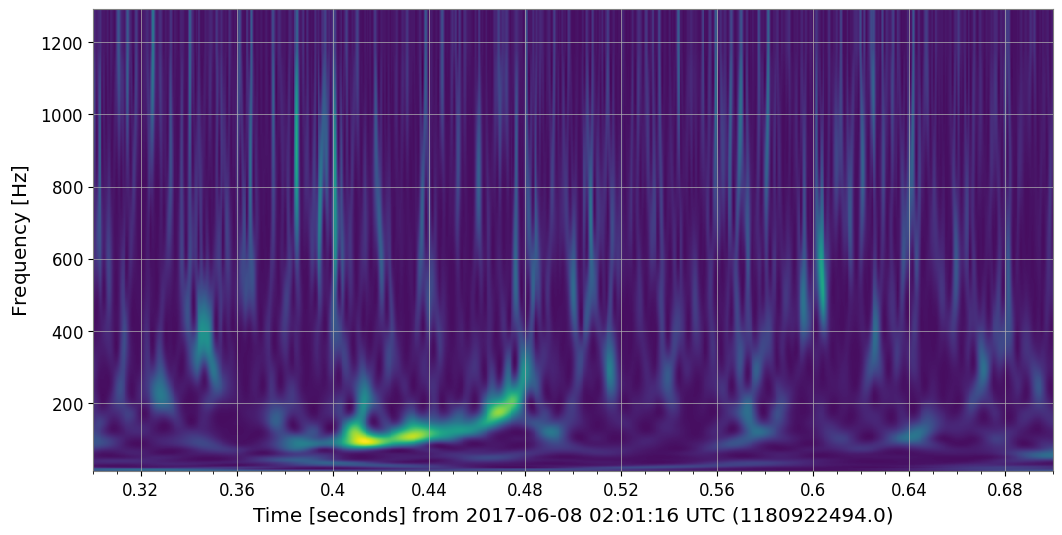

In [14]:
# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot()
plt.show()

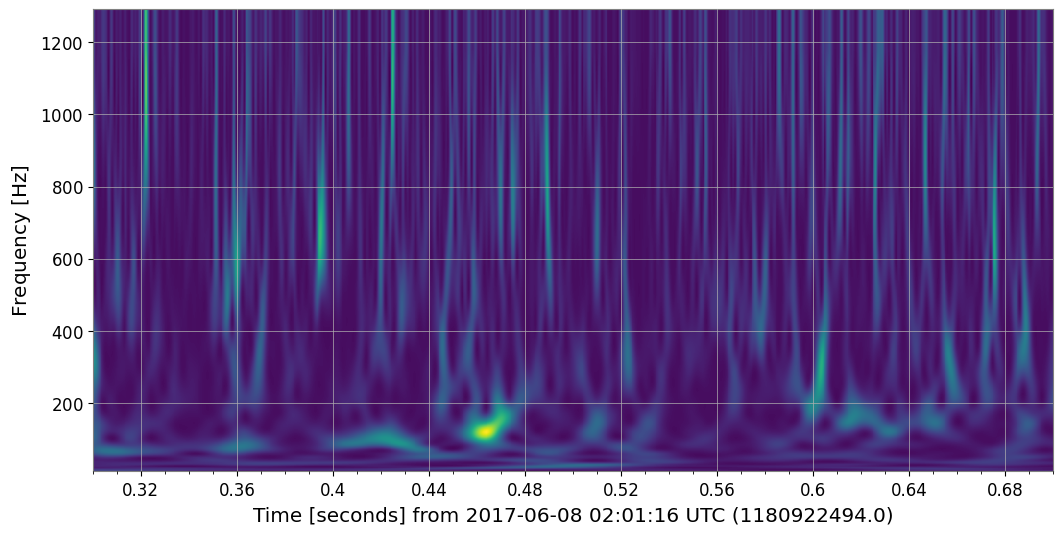

In [11]:
# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot()
plt.show()

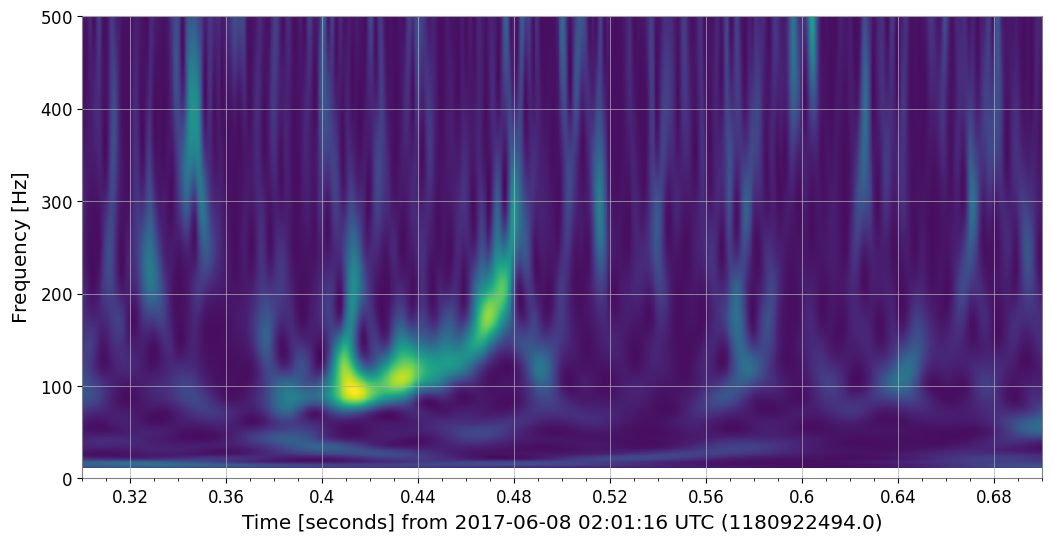

In [13]:
# Plot the Q-transform for Hanford
plot_h1 = q_transform_h1.plot()
plt.ylim(0, 500)
plt.show()

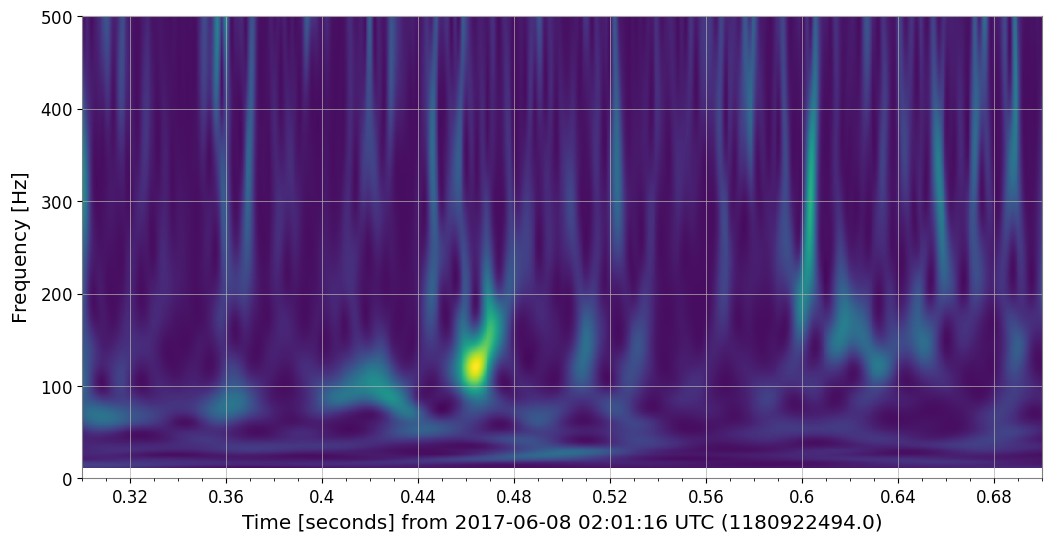

In [15]:
# Plot the Q-transform for Livingston
plot_l1 = q_transform_l1.plot()
plt.ylim(0, 500)
plt.show()